In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
features_df = pd.read_csv(
    r"D:\hiPSC_Morphology_Project\data\processed\features_clustered.csv"
)

print(features_df.shape)
features_df.head()

(69714, 12)


,image_name,label,area,perimeter,eccentricity,solidity,extent,major_axis_length,minor_axis_length,convex_area,equivalent_diameter,cluster
0,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,1,4420.0,306.806133,0.878738,0.855098,0.532851,113.108218,53.986993,5169.0,75.018123,0
1,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,2,1605.0,161.480231,0.778643,0.951393,0.597098,57.766271,36.246447,1687.0,45.205635,0
2,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,3,1216.0,136.781746,0.271627,0.970471,0.643386,41.052407,39.508946,1253.0,39.347926,0
3,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,4,549.0,91.112698,0.779800,0.973404,0.769986,33.845157,21.188053,564.0,26.438769,0
4,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,5,1412.0,146.994949,0.672782,0.957938,0.626442,49.652234,36.734742,1474.0,42.400640,0


In [5]:
print(features_df.columns)

Index(['image_name', 'label', 'area', 'perimeter', 'eccentricity', 'solidity',
       'extent', 'major_axis_length', 'minor_axis_length', 'convex_area',
       'equivalent_diameter', 'cluster'],
      dtype='str')


In [6]:
image_summary = features_df.groupby("image_name").agg(

    colonies=("label","count"),

    mean_area=("area","mean"),
    std_area=("area","std"),

    mean_perimeter=("perimeter","mean"),

    mean_solidity=("solidity","mean"),

    mean_extent=("extent","mean"),

    mean_eccentricity=("eccentricity","mean"),

    mean_major_axis=("major_axis_length","mean"),

    mean_minor_axis=("minor_axis_length","mean"),

    total_area=("area","sum"),

    cluster1_fraction=("cluster","mean")

).reset_index()

In [7]:
print(image_summary.shape)

image_summary.head()

(2474, 12)


,image_name,colonies,mean_area,std_area,mean_perimeter,mean_solidity,mean_extent,mean_eccentricity,mean_major_axis,mean_minor_axis,total_area,cluster1_fraction
0,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,24,5537.083333,13947.133506,276.060487,0.887284,0.606140,0.711442,88.580969,50.268718,132890.0,0.000000
1,001bf60f_3500001005_10X_20170623_11_27(4)-Scen...,48,6754.791667,11563.524551,356.315005,0.842307,0.565390,0.760005,117.223586,61.558849,324230.0,0.000000
2,002a7044_3500001388_10X_20171009_23_20-Scene-0...,26,21680.230769,84639.961019,521.849586,0.888543,0.608333,0.772180,134.578623,74.971758,563686.0,0.038462
3,003201bf_3500000778_10X_20170331_11_27(4)-Scen...,29,3410.896552,4425.298120,245.365659,0.892608,0.586266,0.769683,85.724719,45.153124,98916.0,0.000000
4,0035d714_3500001319_10X_20170922_24_80-Scene-0...,12,68132.083333,151928.556009,1414.877858,0.853914,0.583271,0.742991,273.389624,160.758890,817585.0,0.166667


In [8]:
image_summary.to_csv(

    r"D:\hiPSC_Morphology_Project\data\processed\image_level_features.csv",

    index=False

)

print("Saved!")

Saved!


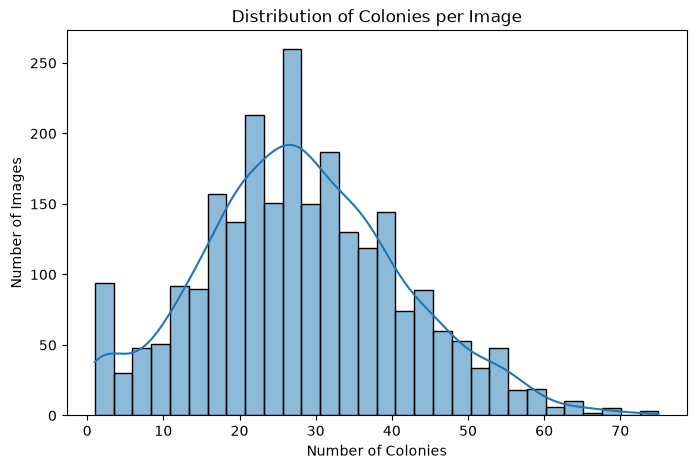

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    image_summary["colonies"],
    bins=30,
    kde=True
)

plt.title("Distribution of Colonies per Image")

plt.xlabel("Number of Colonies")

plt.ylabel("Number of Images")

plt.show()

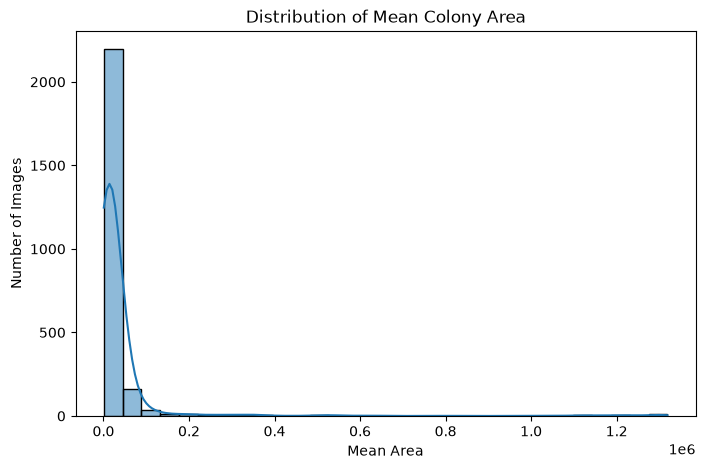

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    image_summary["mean_area"],
    bins=30,
    kde=True
)

plt.title("Distribution of Mean Colony Area")

plt.xlabel("Mean Area")

plt.ylabel("Number of Images")

plt.show()

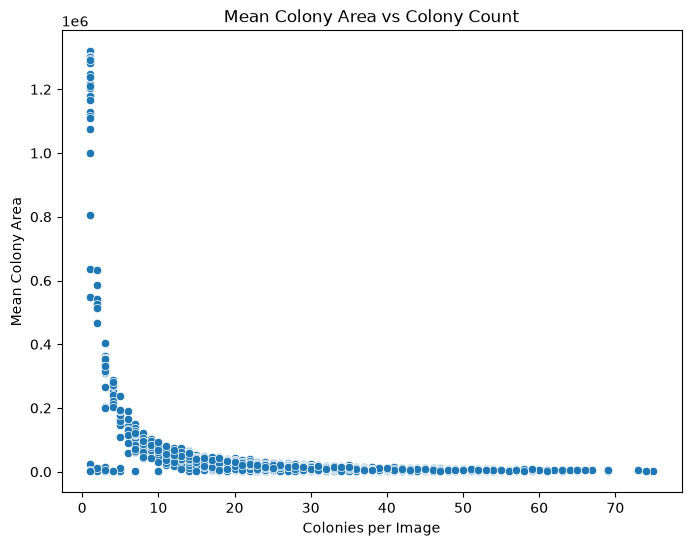

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=image_summary,
    x="colonies",
    y="mean_area"
)

plt.title("Mean Colony Area vs Colony Count")

plt.xlabel("Colonies per Image")

plt.ylabel("Mean Colony Area")

plt.show()

In [12]:
largest = image_summary.sort_values(
    "total_area",
    ascending=False
)

largest.head(10)

,image_name,colonies,mean_area,std_area,mean_perimeter,mean_solidity,mean_extent,mean_eccentricity,mean_major_axis,mean_minor_axis,total_area,cluster1_fraction
523,343e8279_3500002669_10X_20190118_C9_seg.tiff,1,1318639.0,NaN,4834.849348,0.990424,0.779061,0.170245,1306.803442,1287.726487,1318639.0,1.0
1103,6ec5dc28_3500001126_10X_20170728_17_65(10)-Sce...,1,1303032.0,NaN,4264.148771,0.998875,0.786680,0.003023,1288.052775,1288.046890,1303032.0,1.0
1859,bad28547_3500001449_10X_20171023_24_80-Scene-0...,1,1301847.0,NaN,4434.138669,0.991306,0.778687,0.148095,1295.194338,1280.912433,1301847.0,1.0
1817,b59f7952_3500003121_10X_20190607_D3_seg.tiff,1,1300828.0,NaN,5194.958041,0.975797,0.766180,0.286708,1319.991795,1264.575792,1300828.0,1.0
635,3eaae56f_3500000971_10X_20170614_11_27-Scene-0...,1,1295007.0,NaN,4280.959954,0.997896,0.779411,0.168270,1293.394479,1274.951958,1295007.0,1.0
1923,c05f7945_3500000971_10X_20170614_11_27(6)-Scen...,1,1293966.0,NaN,4513.073698,0.982433,0.769206,0.245645,1306.692179,1266.654915,1293966.0,1.0
1495,95a2d093_3500000981_10X_20170616_11_27(5)-Scen...,1,1293914.0,NaN,4428.646245,0.985645,0.773942,0.218038,1301.165199,1269.859461,1293914.0,1.0
2183,da56e069_3500001126_10X_20170728_17_65-Scene-0...,1,1291834.0,NaN,4472.499059,0.982782,0.772698,0.235913,1303.947581,1267.142644,1291834.0,1.0
1807,b44a4ac4_3500003121_10X_20190607_D4_seg.tiff,1,1283943.0,NaN,5651.889066,0.970073,0.767398,0.306323,1317.398902,1254.068513,1283943.0,1.0
1710,aa8c30d1_3500001079_10X_20170717_17_65(3)-Scen...,2,634135.5,887152.431133,2573.458205,0.870773,0.597303,0.393200,712.959261,668.144903,1268271.0,0.5


In [13]:
correlation = image_summary["colonies"].corr(
    image_summary["mean_area"]
)

print("Correlation:", correlation)

Correlation: -0.3692588744285443


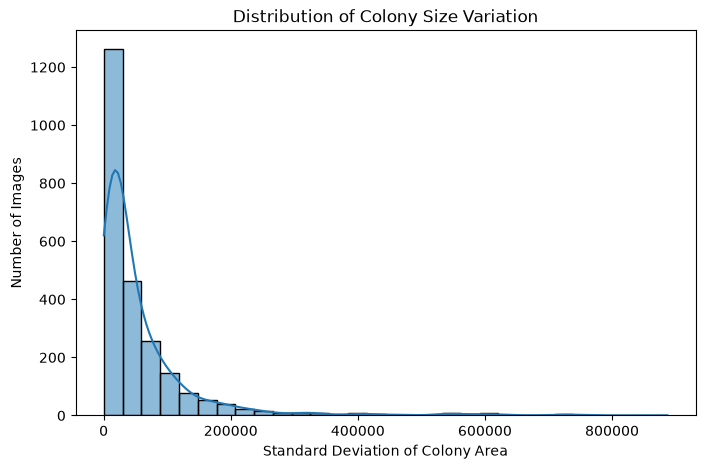

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    image_summary["std_area"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Colony Size Variation")

plt.xlabel("Standard Deviation of Colony Area")

plt.ylabel("Number of Images")

plt.show()